# Persona dataset statistics

Paper-oriented statistics for the six major persona products. This notebook reads only cached JSON/CSV aggregates from `results/`; it never scans the source datasets. Run `profile_datasets.py` only when source artifacts change.

In [10]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

HERE = Path.cwd()
if not (HERE / 'results').exists():
    HERE = Path('/n/netscratch/lu_lab/Lab/xiaominli/LLMResearch/MatrAIx/persona/post_process/dataset_statistics')
RESULTS = HERE / 'results'
IMAGES = RESULTS / 'images'
IMAGES.mkdir(parents=True, exist_ok=True)

stats = json.loads((RESULTS / 'dataset_statistics.json').read_text())
summary = pd.read_csv(RESULTS / 'dataset_summary.csv')
categories = pd.read_csv(RESULTS / 'category_summary.csv')
dimensions = pd.read_csv(RESULTS / 'dimension_summary.csv')
products = {item['product_id']: item for item in stats['products']}

ORDER = ['synthetic', 'wiki', 'amazon', 'stackoverflow', 'prism', 'gss']
LABELS = {item['product_id']: item['display_name'] for item in stats['products']}
COLORS = {
    'synthetic': '#3A6B35', 'wiki': '#2A6F97', 'amazon': '#C65D21',
    'stackoverflow': '#D19A00', 'prism': '#7B4F9D', 'gss': '#5C677D',
}

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 300, 'font.family': 'DejaVu Sans'})
print(f"Cache generated: {stats['generated_at']} | schema dimensions: {stats['schema_dimensions']:,}")

Cache generated: 2026-07-19T21:30:58.074337+00:00 | schema dimensions: 1,290


## Headline table

`exact` means a full scan or a construction-level declaration. Wiki rates are estimates from a deterministic 5,000-row stratified sample; its row count and extraction coverage are exact.

In [2]:
headline = summary.set_index('product_id').loc[ORDER].reset_index()
headline['dataset'] = headline['product_id'].map(LABELS)
headline['available'] = headline['available_rows'].map(lambda value: f'{value:,}')
headline['coverage'] = headline['coverage_pct'].map(lambda value: f'{value:.2f}%')
headline['attributes/persona'] = headline['mean_populated'].map(lambda value: f'{value:,.1f}')
headline['median [P05, P95]'] = headline.apply(
    lambda row: f"{row['median_populated']:,.0f} [{row['p05_populated']:,.0f}, {row['p95_populated']:,.0f}]", axis=1
)
headline['mode'] = headline.apply(
    lambda row: f"{row['scan_mode']} ({'exact' if row['statistics_exact'] else 'estimate'})", axis=1
)
display(headline[['dataset', 'available', 'coverage', 'attributes/persona', 'median [P05, P95]', 'mode']])

,dataset,available,coverage,attributes/persona,"median [P05, P95]",mode
0,Full-DAG synthetic,"10,000,000,000",100.00%,"1,290.0","1,290 [1,290, 1,290]",declared (exact)
1,Wiki-grounded,"1,997,743",93.97%,435.2,"434 [183, 704]",sample (estimate)
2,Amazon Review,"100,000",100.00%,24.8,"19 [3, 64]",full (exact)
3,Stack Overflow survey,"113,335",100.00%,77.2,"73 [48, 118]",full (exact)
4,PRISM Alignment,"1,500",100.00%,178.1,"174 [120, 244]",full (exact)
5,General Social Survey,"75,699",100.00%,14.6,"15 [12, 17]",full (exact)


## Dataset scale

A logarithmic axis is required because the products span from 1,500 to 10 billion personas.

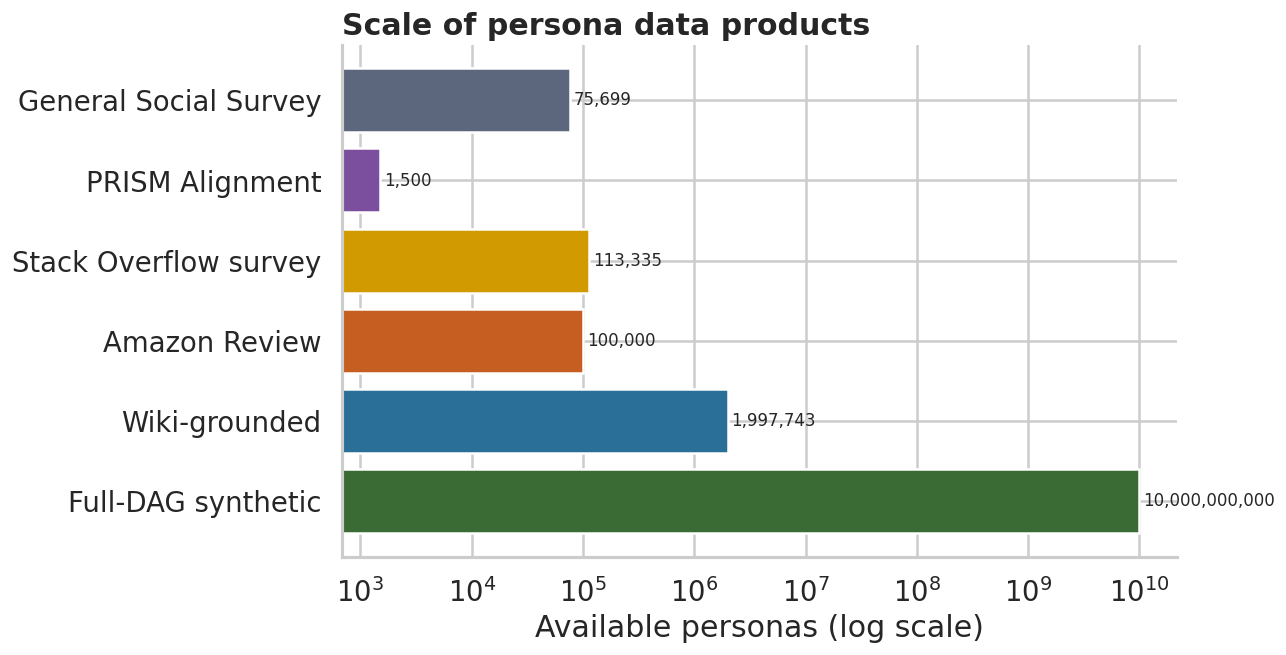

In [3]:
plot_df = headline.copy()
fig, ax = plt.subplots(figsize=(11, 5.8))
bars = ax.barh(
    [LABELS[item] for item in ORDER],
    plot_df.set_index('product_id').loc[ORDER, 'available_rows'],
    color=[COLORS[item] for item in ORDER],
)
ax.set_xscale('log')
ax.set_xlabel('Available personas (log scale)')
ax.set_ylabel('')
ax.set_title('Scale of persona data products', loc='left', weight='bold')
for bar, product_id in zip(bars, ORDER):
    value = plot_df.set_index('product_id').loc[product_id, 'available_rows']
    ax.text(value * 1.08, bar.get_y() + bar.get_height()/2, f'{value:,}', va='center', fontsize=10)
sns.despine(ax=ax)
fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(IMAGES / f'dataset_scale.{ext}', bbox_inches='tight')
plt.show()

## Populated attributes per persona

A populated attribute has a non-null, non-empty value. Whiskers show P05-P95 and points show the median. Synthetic personas assign all 1,290 attributes by construction.

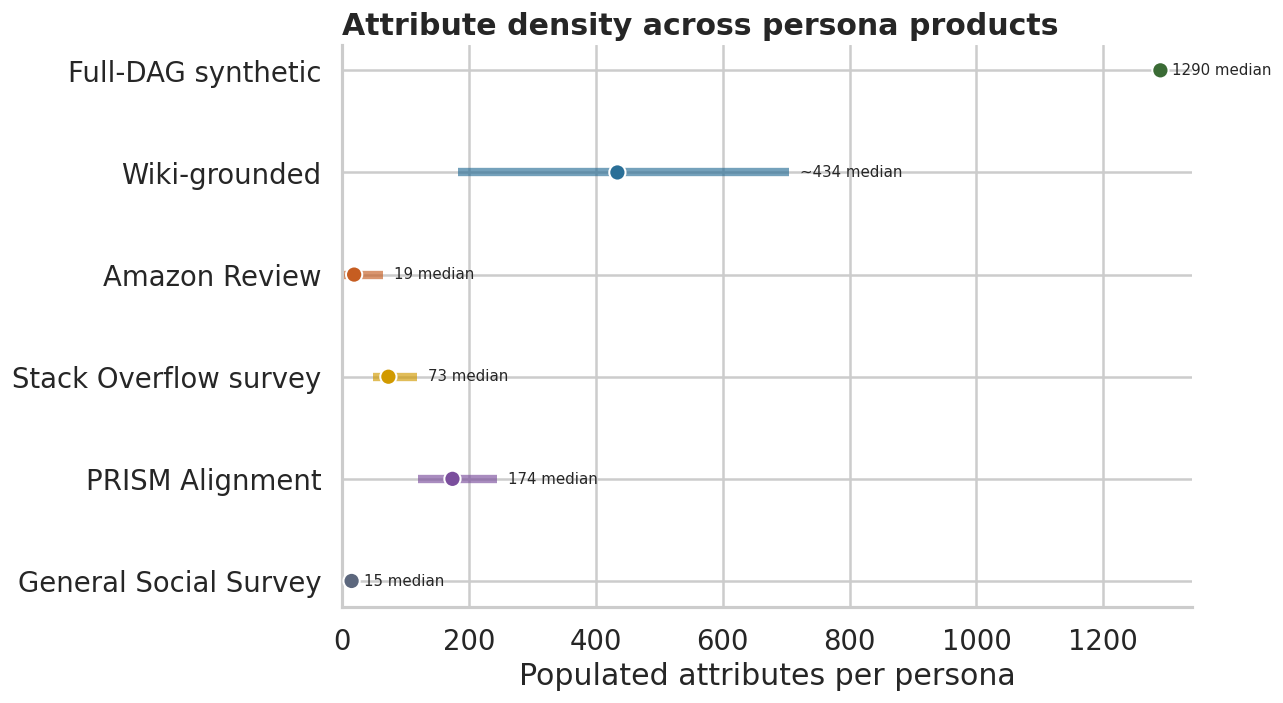

In [4]:
metric = headline.set_index('product_id').loc[ORDER]
y = np.arange(len(ORDER))
median = metric['median_populated'].to_numpy()
low = metric['p05_populated'].to_numpy()
high = metric['p95_populated'].to_numpy()
fig, ax = plt.subplots(figsize=(11, 6.2))
ax.hlines(y, low, high, color=[COLORS[item] for item in ORDER], linewidth=5, alpha=.65)
ax.scatter(median, y, s=95, color=[COLORS[item] for item in ORDER], edgecolor='white', linewidth=1.2, zorder=3)
ax.set_yticks(y, [LABELS[item] for item in ORDER])
ax.invert_yaxis()
ax.set_xlim(0, 1340)
ax.set_xlabel('Populated attributes per persona')
ax.set_title('Attribute density across persona products', loc='left', weight='bold')
for index, product_id in enumerate(ORDER):
    marker = '~' if not bool(metric.loc[product_id, 'statistics_exact']) else ''
    ax.text(high[index] + 18, index, f"{marker}{median[index]:.0f} median", va='center', fontsize=9)
sns.despine(ax=ax)
fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(IMAGES / f'populated_attributes_distribution.{ext}', bbox_inches='tight')
plt.show()

## Assignment provenance

Shares are computed over emitted fields. Synthetic uses graph assignment rather than evidence-grounded attribution. Missing labels expose contract drift in legacy Wiki outputs.

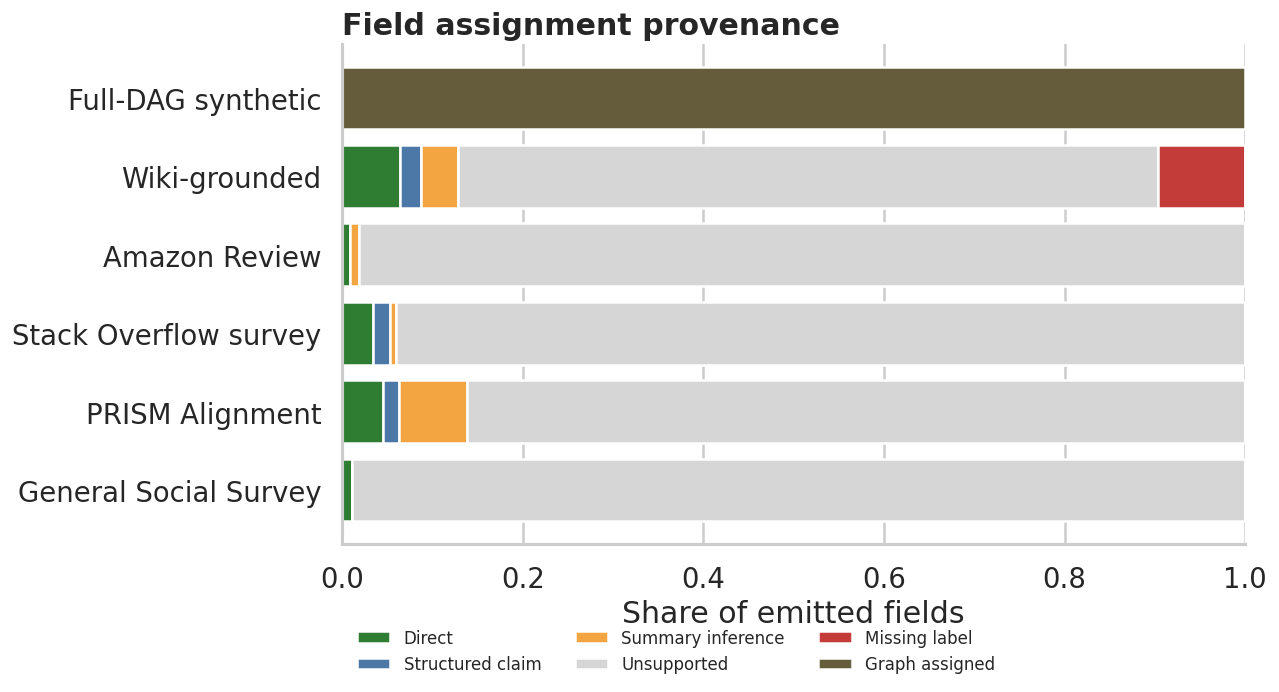

In [5]:
assignment_order = ['direct', 'structured_claim', 'summary_inference', 'unsupported', 'missing', 'graph_assigned']
assignment_labels = {
    'direct': 'Direct', 'structured_claim': 'Structured claim',
    'summary_inference': 'Summary inference', 'unsupported': 'Unsupported',
    'missing': 'Missing label', 'graph_assigned': 'Graph assigned',
}
assignment_colors = {
    'direct': '#2E7D32', 'structured_claim': '#4C78A8',
    'summary_inference': '#F2A541', 'unsupported': '#D6D6D6',
    'missing': '#C43C39', 'graph_assigned': '#655C3B',
}
matrix = []
for product_id in ORDER:
    counts = products[product_id]['assignment_types']
    total = sum(counts.values())
    matrix.append([counts.get(item, 0) / total for item in assignment_order])
matrix = np.asarray(matrix)
fig, ax = plt.subplots(figsize=(11, 6.2))
left = np.zeros(len(ORDER))
for column, assignment_type in enumerate(assignment_order):
    values = matrix[:, column]
    ax.barh(
        [LABELS[item] for item in ORDER], values, left=left,
        label=assignment_labels[assignment_type], color=assignment_colors[assignment_type],
    )
    left += values
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel('Share of emitted fields')
ax.set_title('Field assignment provenance', loc='left', weight='bold')
ax.legend(ncol=3, frameon=False, bbox_to_anchor=(0, -0.14), loc='upper left', fontsize=10)
sns.despine(ax=ax)
fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(IMAGES / f'assignment_type_mix.{ext}', bbox_inches='tight')
plt.show()

## Category coverage

Mean populated fields per persona, normalized by each category's number of dimensions. This reveals which behavioral surfaces each source can actually support.

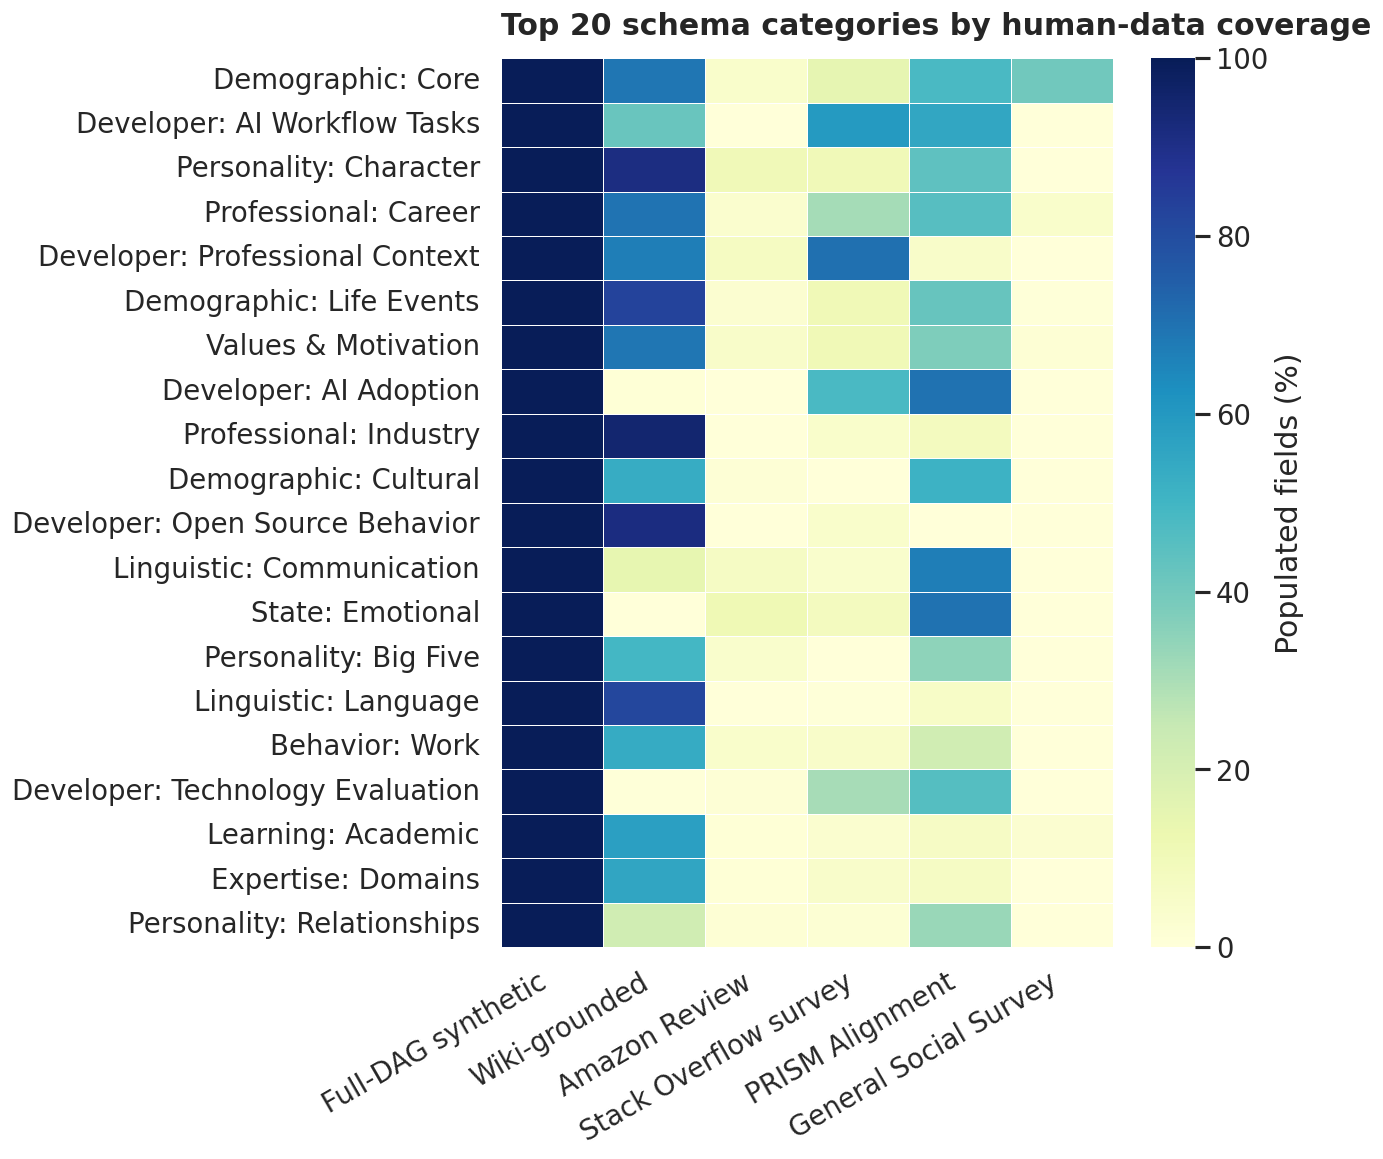

In [6]:
heat = categories.pivot(index='category', columns='product_id', values='populated_rate')[ORDER]
human_mean = heat.drop(columns='synthetic').mean(axis=1)
selected_categories = human_mean.sort_values(ascending=False).head(20).index
heat = heat.loc[selected_categories]
fig, ax = plt.subplots(figsize=(11, 10))
sns.heatmap(
    heat * 100, cmap='YlGnBu', vmin=0, vmax=100, linewidths=.4,
    cbar_kws={'label': 'Populated fields (%)'}, ax=ax,
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels([LABELS[item] for item in ORDER], rotation=30, ha='right')
ax.set_title('Top 20 schema categories by human-data coverage', loc='left', weight='bold', pad=14)
fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(IMAGES / f'category_coverage_heatmap.{ext}', bbox_inches='tight')
plt.show()

## Grounding and output quality

Evidence and description rates use populated fields as the denominator. They describe output completeness, not factual correctness. Synthetic and rule-only GSS do not require textual evidence.

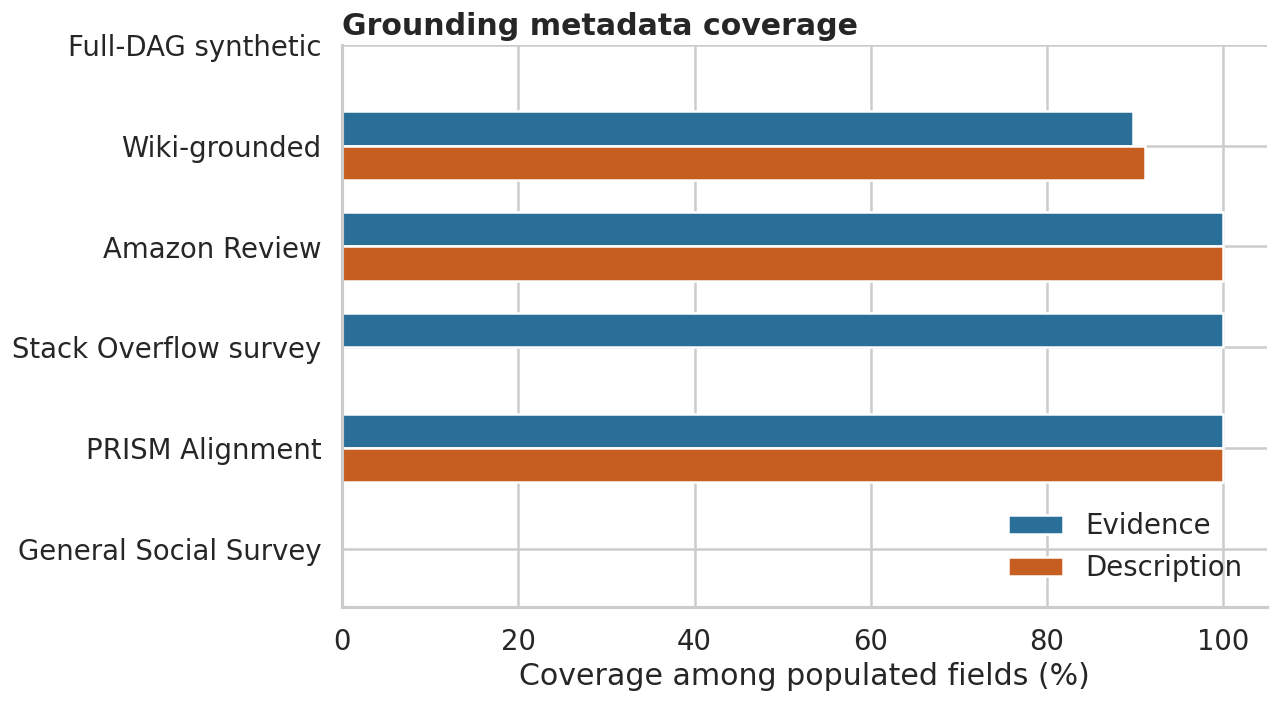

In [ ]:
quality = headline.set_index('product_id').loc[ORDER].copy()
quality = quality[['evidence_coverage', 'description_coverage']].rename(
    columns={'evidence_coverage': 'Evidence', 'description_coverage': 'Description'}
)
y = np.arange(len(ORDER))
height = .34
fig, ax = plt.subplots(figsize=(11, 6.2))
ax.barh(y - height/2, quality['Evidence'] * 100, height, label='Evidence', color='#2A6F97')
ax.barh(y + height/2, quality['Description'] * 100, height, label='Description', color='#C65D21')
ax.set_yticks(y, [LABELS[item] for item in ORDER])
ax.invert_yaxis()
ax.set_xlim(0, 105)
ax.set_xlabel('Coverage among populated fields (%)')
ax.set_ylabel('')
ax.set_title('Grounding metadata coverage', loc='left', weight='bold')
ax.legend(frameon=False, loc='lower right')
sns.despine(ax=ax)
fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(IMAGES / f'grounding_metadata_coverage.{ext}', bbox_inches='tight')
plt.show()

## Contract diagnostics and paper notes

These diagnostics should be reported as data-quality limitations. Wiki metrics are estimated, while its anomaly counts are sample counts rather than corpus totals.

In [9]:
diagnostics = headline[[
    'product_id', 'rows_scanned', 'unknown_field_occurrences',
    'duplicate_field_ids', 'off_schema_values'
]].copy()
diagnostics['dataset'] = diagnostics['product_id'].map(LABELS)
display(diagnostics[[
    'dataset', 'rows_scanned', 'unknown_field_occurrences',
    'duplicate_field_ids', 'off_schema_values'
]])

print('Paper interpretation notes:')
for product_id in ORDER:
    product = products[product_id]
    exact = 'exact' if product['statistics_exact'] else 'estimated'
    print(f"- {LABELS[product_id]}: {exact}; {product['notes']}")

print(f'\nFigures saved to: {IMAGES}')

,dataset,rows_scanned,unknown_field_occurrences,duplicate_field_ids,off_schema_values
0,Full-DAG synthetic,0,0,0,0
1,Wiki-grounded,5000,152,643,112240
2,Amazon Review,100000,0,0,1134
3,Stack Overflow survey,113335,0,0,677
4,PRISM Alignment,1500,0,0,0
5,General Social Survey,75699,0,0,0


Paper interpretation notes:
- Full-DAG synthetic: exact; No payload scan; completed production manifests are the source of scale.
- Wiki-grounded: estimated; 5,000-row deterministic stratified shard-head sample; rates are estimates.
- Amazon Review: exact; Final 256-bucket assembly: 167 continuation plus 89 source buckets.
- Stack Overflow survey: exact; Translated files only; raw extraction files are not double counted.
- PRISM Alignment: exact; Full validated v1.1 gzip shard.
- General Social Survey: exact; Full scan of five validated gzip shards.

Figures saved to: /n/netscratch/lu_lab/Lab/xiaominli/LLMResearch/MatrAIx/persona/post_process/dataset_statistics/results/images
